In [1]:
import os
import glob
import dask
import numpy as np
import xarray as xr
import cftime
import pop_tools
import gsw
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib as mpl
import pandas as pd

In [2]:
# AMS widths in inches
one_col = 3.167  # 19 picas
two_col = 6.5    # 39 picas

# Set defaults
plt.rcParams.update({
    'figure.figsize': (two_col, two_col * 0.6),
    'font.size': 11,
    'axes.titlesize': 11,   # match global font size for titles
    'savefig.dpi': 300,
})


# Prepare time series to visualise 

In [3]:
output_dir = '/Data/skd/scratch/innag3580/comp/'
output_filename = 'var_ensemble_mean.nc'
output_path = os.path.join(output_dir, output_filename)

# Read the ensemble mean data
ds_ensemble_mean = xr.open_dataset(output_path)


In [4]:
grid_name = 'POP_gx1v7'
grid = pop_tools.get_grid(grid_name)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## compute densities

In [5]:
CT = gsw.conversions.CT_from_pt(ds_ensemble_mean['SALT'], ds_ensemble_mean['SALT'])
sigma2 = gsw.density.sigma2(ds_ensemble_mean['SALT'], CT)
sigma2 = xr.DataArray(sigma2, name='DENS2', dims=ds_ensemble_mean['SALT'].dims, coords=ds_ensemble_mean['SALT'].coords)

ds_dens = ds_ensemble_mean
ds_dens = ds_dens.drop_vars('TEMP')
ds_dens['DENS2'] = sigma2

# contribution from salt only
mean_temp = ds_ensemble_mean['SALT'].sel(time=slice(None, '2025')).mean('time')
mean_temp = mean_temp.expand_dims({'time': ds_ensemble_mean['SALT'].time})
CT_salt = gsw.conversions.CT_from_pt(ds_ensemble_mean['SALT'], mean_temp)
sigma2_salt = gsw.density.sigma2(ds_ensemble_mean['SALT'], CT_salt)
sigma2_salt = xr.DataArray(sigma2_salt, name='DENS2',
                           dims=ds_ensemble_mean['SALT'].dims,
                           coords=ds_ensemble_mean['SALT'].coords)
ds_dens['DENS2_salt'] = sigma2_salt

# contribution from temp only
mean_salt = ds_ensemble_mean['SALT'].sel(time=slice(None, '2025')).mean('time')
mean_salt = mean_salt.expand_dims({'time': ds_ensemble_mean['SALT'].time})
CT_temp = gsw.conversions.CT_from_pt(mean_salt, ds_ensemble_mean['SALT'])
sigma2_temp = gsw.density.sigma2(mean_salt, CT_temp)
sigma2_temp = xr.DataArray(sigma2_temp, name='DENS2', 
                           dims=ds_ensemble_mean['SALT'].dims, 
                           coords=ds_ensemble_mean['SALT'].coords)
ds_dens['DENS2_temp'] = sigma2_temp

In [6]:
def relative_anomaly(da, end_year='2025'):
    ref = da.sel(time=slice(None, end_year)).mean('time')
    return (da - ref) / ref

In [7]:
# SPNA density 
weights = grid.dz * grid.TAREA
weights = weights.fillna(0)
spna_dens = ds_dens.DENS2.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])
spna_dens_salt = ds_dens.DENS2_salt.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])
spna_dens_temp = ds_dens.DENS2_temp.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])

In [8]:
delta_dens = relative_anomaly(spna_dens)
delta_dens_salt = relative_anomaly(spna_dens_salt)
delta_dens_temp = relative_anomaly(spna_dens_temp)

## load smoc time series

In [9]:
output_dir = '/Data/skd/scratch/innag3580/comp/smoc/'
output = os.path.join(output_dir, 'smoc55_ensemble_mean.nc')
smoc55 = xr.open_dataarray(output).resample(time='1Y').mean().sel(time=slice(None, '2025'))
delta_smoc55 = relative_anomaly(smoc55)

# Plot dmoc with density

In [10]:
# Ensure the colors dictionary is defined (as per your earlier code)
colors = {
    'spna_dens': '#000000',      # Black
    'dens_salt': '#003959',      # Darker Blue (Midpoint to black)
    'dens_temp': '#E69F00',      # Orange
    'smoc_55':   '#016E89',      # Bluish Green/Teal
}

# Time definitions
years = np.arange(1875, 2015, 25)
x_ticks = pd.to_datetime(years, format='%Y')
x_labels = [str(year) for year in years]

# Mock data for the three density lines using delta_smoc55
#dens = delta_smoc55 * 1.5   # Total Density (Highest, Solid)
#dens_salt = delta_smoc55 * 1.0 + 0.01 # Salt Contribution (Mid, Dashed)
#dens_temp = delta_smoc55 * 0.5 - 0.01 # Temp Contribution (Lowest, Dotted)

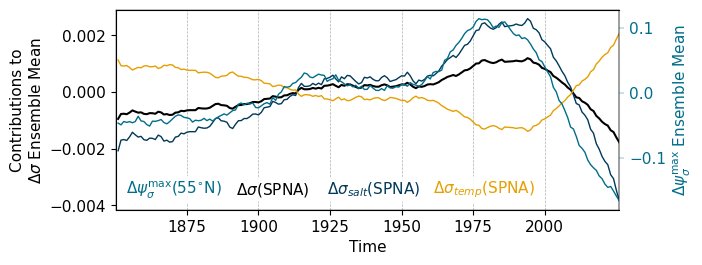

In [11]:
# --- 2. FIGURE SETUP ---
fig, ax = plt.subplots(figsize=(two_col, two_col * 0.4)) 
bbox_props = dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle="round,pad=0.2")

# --- 3. PRIMARY Y-AXIS (Density) ---
ax.plot(delta_smoc55.time + 1, delta_dens, linewidth=1.5, color=colors['spna_dens'])
ax.plot(delta_smoc55.time + 1, delta_dens_salt, linewidth=1, color=colors['dens_salt'])
ax.plot(delta_smoc55.time + 1, delta_dens_temp, linewidth=1, color=colors['dens_temp'])

# --- 4. SECONDARY Y-AXIS (Twin) ---
ax2 = ax.twinx() 
ax2.plot(delta_smoc55.time + 1, delta_smoc55, linewidth=1, color=colors['smoc_55'])

# --- 5. AESTHETICS ---
ax.grid(visible=True, axis='x', linestyle='--', linewidth=0.5) 

for spine in ax.spines.values():
    spine.set_linewidth(0.3)

ax.set_xlim(pd.to_datetime('1850-02-01'), pd.to_datetime('2025-12-31'))
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, ha='center')
ax.set_ylabel('Contributions to\n'+r'$\Delta \sigma$ Ensemble Mean')
ax.set_xlabel('Time')

ax2.spines['right'].set_linewidth(0.3)
ax2.tick_params(axis='y', colors=colors['smoc_55'], width=0.3) 
ax2.set_ylabel(r'$\Delta \psi^{\max}_{\sigma}$ Ensemble Mean', color=colors['smoc_55'])

# --- 6. HORIZONTAL TEXT LEGEND ---
y_pos = 0.1 
x_positions = [0.02, 0.24, 0.42, 0.63] 
legend_items = [
    (r'$\Delta \psi^{\max}_{\sigma}(55^{\circ}\mathrm{N})$', colors['smoc_55']),
    (r'$\Delta \sigma$(SPNA)', colors['spna_dens']),
    (r'$\Delta \sigma_{salt}$(SPNA)', colors['dens_salt']),
    (r'$\Delta \sigma_{temp}$(SPNA)', colors['dens_temp']),
]

for (label, color), x in zip(legend_items, x_positions):
    ax.text(x, y_pos, label, transform=ax.transAxes,
            color=color, ha='left', va='center', bbox=bbox_props)

plt.savefig('Figure_trend.png', bbox_inches='tight', dpi=300, transparent=False)